**This notebook is where we implement random forest**

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# --- 1. Load Data ---
processed_data_path = 'C:/Users/Admin/projects/Omer_Sen_Thesis_Quantitative_Finance/02_Data_Collection_and_Preperation/Proccessed_Data/sp500_factors_final_for_modeling.parquet' 

try:
    df = pd.read_parquet(processed_data_path)
    print(f"Successfully loaded data from {processed_data_path}. Shape: {df.shape}")
    df['date'] = pd.to_datetime(df['date'])
except FileNotFoundError:
    print(f"Error: File not found at {processed_data_path}. Please ensure the path is correct.")
    df = None
except Exception as e:
    print(f"An error occurred loading the Parquet file: {e}")
    df = None

if df is not None:
    # --- Define Factor Columns (Predictors X) and Target (y) ---
    all_columns = df.columns.tolist()
    known_identifiers_and_target = [
        'permno', 'date', 'ret', 'target_ret_t_plus_1' 
    ]

    non_predictor_cols = [col for col in known_identifiers_and_target if col in df.columns]
    factor_columns = [col for col in df.columns if col not in non_predictor_cols and df[col].dtype == 'float64']
    
    
    factor_columns = list(set(factor_columns)) # Use set to ensure uniqueness

    print(f"Identified {len(factor_columns)} predictor (factor + indicator) columns.")
    if not factor_columns or len(factor_columns) < 150:
        print("Warning: Number of identified predictor columns seems low. Please verify.")

    TARGET_COL = 'target_ret_t_plus_1'

    # Ensure no NaNs in target or crucial columns (should have been handled, but good check)
    df.dropna(subset=[TARGET_COL] + ['permno', 'date'], inplace=True)
    # For Random Forest, it can handle NaNs in features if underlying decision trees can (scikit-learn's can't by default)
    # However, our factors should be imputed and standardized from previous steps.
    # If any NaNs remain in factor_columns, GridSearchCV might fail.
    if df[factor_columns].isnull().any().any():
        print("Warning: NaNs found in factor columns. RF/GridSearchCV might fail. Consider re-running imputation or fillna(0).")
        # df[factor_columns] = df[factor_columns].fillna(0) # A fallback, but investigate source of NaNs

    print(f"Shape after dropping any NaNs in target/key IDs: {df.shape}")


Successfully loaded data from C:/Users/Admin/projects/Omer_Sen_Thesis_Quantitative_Finance/02_Data_Collection_and_Preperation/Proccessed_Data/sp500_factors_final_for_modeling.parquet. Shape: (344511, 156)
Identified 152 predictor (factor + indicator) columns.
Shape after dropping any NaNs in target/key IDs: (344511, 156)


In [3]:
# --- 2. Define Date Ranges ---
print("\n--- Defining Date Ranges ---")
train_start_date = pd.to_datetime('1965-01-31')
train_end_date = pd.to_datetime('1989-12-31')
    
validation_start_date = pd.to_datetime('1990-01-31')
validation_end_date = pd.to_datetime('2004-12-31')
    
oos_test_start_date = pd.to_datetime('2005-01-31')
oos_test_end_date = pd.to_datetime('2023-12-31') 

print(f"Initial Training: {train_start_date.date()} to {train_end_date.date()}")
print(f"Validation of Strategy: {validation_start_date.date()} to {validation_end_date.date()}")
print(f"Out-of-Sample Test: {oos_test_start_date.date()} to {oos_test_end_date.date()}")



--- Defining Date Ranges ---
Initial Training: 1965-01-31 to 1989-12-31
Validation of Strategy: 1990-01-31 to 2004-12-31
Out-of-Sample Test: 2005-01-31 to 2023-12-31


In [4]:
# --- 3&4. Split Data (Initial Split for Training and Validation of Strategy) ---
print("\n--- Splitting Data (Initial Train & Validation Strategy Sets) ---")
train_df = df[(df['date'] >= train_start_date) & (df['date'] <= train_end_date)].copy()
validation_strategy_df = df[(df['date'] >= validation_start_date) & (df['date'] <= validation_end_date)].copy()

print(f"Initial Training Set: {len(train_df)} observations ({train_df['date'].min().date()} to {train_df['date'].max().date() if not train_df.empty else 'N/A'})")
print(f"Validation Strategy Set: {len(validation_strategy_df)} observations ({validation_strategy_df['date'].min().date()} to {validation_strategy_df['date'].max().date() if not validation_strategy_df.empty else 'N/A'})")
    
if not train_df.empty:
        X_train_initial = train_df[factor_columns]
        y_train_initial = train_df[TARGET_COL]
else:
    print("Initial training set is empty.")
    X_train_initial, y_train_initial = None, None


--- Splitting Data (Initial Train & Validation Strategy Sets) ---
Initial Training Set: 148018 observations (1965-01-31 to 1989-12-31)
Validation Strategy Set: 88892 observations (1990-01-31 to 2004-12-31)


In [5]:
# --- 5. Initial RandomForest Hyperparameter Tuning Setup (on 1965-1989 data) ---
print("\n--- Setting up for RandomForest Hyperparameter Tuning (Initial Fit with GridSearchCV) ---")
if X_train_initial is not None and y_train_initial is not None:
        
    param_grid_rf = {
        'max_depth': [3, 5, 6], # Adjusted from 1-6 for initial speed, paper uses 1-6
        'min_samples_split': [50, 100], 
        'min_samples_leaf': [20, 50],   
        'max_features': ['sqrt', 10, 20, 30, 50] # 'sqrt' is ~12-13, 30 as per paper indication
        # n_estimators will be set to 300 directly in the estimator for the main loops
    }
        
    # Using fewer splits for initial faster run of GridSearchCV
    cv_splitter = TimeSeriesSplit(n_splits=3) 

    print("Performing GridSearchCV for RandomForest on initial training data (1965-1989)...")
    print(f"Parameter grid: {param_grid_rf}")
        
    # For this initial test, use a smaller n_estimators for speed. Use 300 in the main loops.
    rf_grid_search = GridSearchCV(
        estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1), # Reduced n_estimators for this test
        param_grid=param_grid_rf,
        cv=cv_splitter, 
        scoring='neg_mean_squared_error', 
        n_jobs=1, # n_jobs for GridSearchCV itself
        verbose=1 
    )
        
    # Ensure data is sorted by date for TimeSeriesSplit
    # df should be sorted by permno, then date from previous notebook's target creation step.
    # Slicing should maintain this order for train_df.
    # I X_train_initial contains 'date' and 'permno', sort by them explicitly.
    # However, for RF, the order of rows for training doesn't matter as much as for time-series specific models,
    # but TimeSeriesSplit itself requires ordered data.
    if 'date' in X_train_initial.columns:
             X_train_initial_sorted = X_train_initial.sort_values(by=['date', 'permno']) # Simplified sort for this stage
    else: # If no date column, assume it's already correctly ordered or sort by index
             X_train_initial_sorted = X_train_initial.sort_index()
    y_train_initial_sorted = y_train_initial.loc[X_train_initial_sorted.index]
        
    rf_grid_search.fit(X_train_initial_sorted, y_train_initial_sorted)
        
    print(f"\nBest parameters found on initial training data: {rf_grid_search.best_params_}")
    best_rf_initial = rf_grid_search.best_estimator_
        
    # Evaluate on the *first year* of the validation_strategy set (e.g., 1990)
    if not validation_strategy_df.empty and validation_strategy_df['date'].dt.year.min() <= 1990:
        X_val_1990 = validation_strategy_df[validation_strategy_df['date'].dt.year == 1990][factor_columns]
        y_val_1990 = validation_strategy_df[validation_strategy_df['date'].dt.year == 1990][TARGET_COL]
            
        if not X_val_1990.empty and not y_val_1990.empty:
            predictions_1990_rf = best_rf_initial.predict(X_val_1990)
            mse_1990_rf = mean_squared_error(y_val_1990, predictions_1990_rf)
                
            mean_initial_train_ret_for_r2 = y_train_initial.mean() 
            r2_1990_rf = 1 - (np.sum((y_val_1990 - predictions_1990_rf)**2) / 
                                  np.sum((y_val_1990 - mean_initial_train_ret_for_r2)**2))

            print(f"\nPerformance of best RF (from initial train) on 1990 (validation set):")
            print(f"  MSE: {mse_1990_rf:.6f}")
            print(f"  OOS R2 (vs initial train mean): {r2_1990_rf:.4f}")
        else:
            print("No data for 1990 in validation_strategy_df to evaluate, or y_val_1990 is empty.")
    else:
        print("Year 1990 not found or validation_strategy_df is empty for initial RF check.")
            
else:
    print("Cannot proceed with RandomForest setup as initial training data is missing.")


--- Setting up for RandomForest Hyperparameter Tuning (Initial Fit with GridSearchCV) ---
Performing GridSearchCV for RandomForest on initial training data (1965-1989)...
Parameter grid: {'max_depth': [3, 5, 6], 'min_samples_split': [50, 100], 'min_samples_leaf': [20, 50], 'max_features': ['sqrt', 10, 20, 30, 50]}
Fitting 3 folds for each of 60 candidates, totalling 180 fits

Best parameters found on initial training data: {'max_depth': 6, 'max_features': 50, 'min_samples_leaf': 50, 'min_samples_split': 50}

Performance of best RF (from initial train) on 1990 (validation set):
  MSE: 0.013212
  OOS R2 (vs initial train mean): 0.0007


In [6]:
import time

In [7]:

print("\n--- Starting RF Hyperparameter Strategy Validation Loop (Predicting for 1990-2004) ---")

validation_predict_years = range(validation_start_date.year, validation_end_date.year + 1)

# Store results
results_rf_adaptive_cv = []
params_chosen_rf_adaptive = [] # Store best params for each year

results_rf_fixed_params = []
# Parameters for the fixed strategy are those found from the initial 1965-1989 fit
fixed_hyperparams = rf_grid_search.best_params_
print(f"Using fixed hyperparameters for benchmark strategy: {fixed_hyperparams}")
# Ensure n_estimators is set to 300 for the fixed strategy, as per paper (if not already in best_params_)
if 'n_estimators' not in fixed_hyperparams: # n_estimators was not part of grid search previously
    fixed_hyperparams_for_run = fixed_hyperparams.copy()
    fixed_hyperparams_for_run['n_estimators'] = 100 
else: # if n_estimators somehow got into best_params_ (e.g. from a different grid)
    fixed_hyperparams_for_run = fixed_hyperparams.copy()
    fixed_hyperparams_for_run['n_estimators'] = 100 # Override to ensure 300

# Parameter grid for yearly GridSearchCV (should be the same as used before)
# Ensure this matches what you finalized based on GKX
param_grid_rf_yearly = {
    'max_depth': [3, 5, 6], 
    'min_samples_split': [50, 100], 
    'min_samples_leaf': [20, 50],   
    'max_features': ['sqrt',10, 30, 50] # Added 50 back based on your initial best finding
}
cv_splitter_yearly = TimeSeriesSplit(n_splits=3) # Using 3 for speed, paper might imply more robust CV (e.g. 5 or 10 for financial data)

loop_start_time = time.time()




--- Starting RF Hyperparameter Strategy Validation Loop (Predicting for 1990-2004) ---
Using fixed hyperparameters for benchmark strategy: {'max_depth': 6, 'max_features': 50, 'min_samples_leaf': 50, 'min_samples_split': 50}


In [11]:

for year_to_predict in validation_predict_years:
    year_start_time = time.time()
    print(f"\nProcessing for year to predict: {year_to_predict}")
    
    current_train_end_date = pd.to_datetime(f"{year_to_predict-1}-12-31")
    current_train_df = df[(df['date'] >= train_start_date) & (df['date'] <= current_train_end_date)].copy()
    
    current_test_start_date = pd.to_datetime(f"{year_to_predict}-01-01")
    current_test_end_date = pd.to_datetime(f"{year_to_predict}-12-31")
    current_test_df = df[(df['date'] >= current_test_start_date) & (df['date'] <= current_test_end_date)].copy()

    if current_train_df.empty or current_test_df.empty:
        print(f"  Skipping {year_to_predict}: not enough data for train or test.")
        params_chosen_rf_adaptive.append({'year': year_to_predict, 'params': np.nan})
        continue

    # Sort current training data for TimeSeriesSplit

    X_current_train = current_train_df[factor_columns]
    y_current_train = current_train_df[TARGET_COL]
    
    X_current_test = current_test_df[factor_columns]
    y_current_test_actual = current_test_df[TARGET_COL]

# --- Strategy 1: Adaptive Hyperparameters (Yearly GridSearchCV) ---
    print(f"  Strategy 1 (Adaptive RF): Training on {len(X_current_train)} obs up to {current_train_end_date.date()}")
    
    # Use n_estimators=300 as per paper for the actual yearly models
    rf_gs_yearly = GridSearchCV(
        estimator=RandomForestRegressor(n_estimators=100, random_state=year_to_predict, n_jobs=-1),
        param_grid=param_grid_rf_yearly,
        cv=cv_splitter_yearly, 
        scoring='neg_mean_squared_error',
        n_jobs=1, # GridSearchCV's own parallelism for folds
        verbose=0 # Reduce verbosity for the loop, can set to 1 for more details
    )
    rf_gs_yearly.fit(X_current_train, y_current_train)
    best_params_adaptive = rf_gs_yearly.best_params_
    params_chosen_rf_adaptive.append({'year': year_to_predict, 'params': best_params_adaptive})
    print(f"    Best RF params for predicting {year_to_predict}: {best_params_adaptive}")
    
    model_adaptive_rf = rf_gs_yearly.best_estimator_ # This already has n_estimators=300
    predictions_adaptive_rf = model_adaptive_rf.predict(X_current_test)
    results_rf_adaptive_cv.append(pd.DataFrame({'date': current_test_df['date'], 
                                             'permno': current_test_df['permno'],
                                             'actual_ret': y_current_test_actual, 
                                             'predicted_ret_adaptive_rf': predictions_adaptive_rf}))
   # --- Strategy 2: Fixed Hyperparameters (from initial 1965-1989 fit, but with n_estimators=300) ---
    print(f"  Strategy 2 (Fixed RF Params): Training on {len(X_current_train)} obs")
    model_fixed_rf = RandomForestRegressor(**fixed_hyperparams_for_run, random_state=year_to_predict, n_jobs=-1)
    model_fixed_rf.fit(X_current_train, y_current_train)
    predictions_fixed_rf = model_fixed_rf.predict(X_current_test)
    results_rf_fixed_params.append(pd.DataFrame({'date': current_test_df['date'],
                                                 'permno': current_test_df['permno'],
                                                 'actual_ret': y_current_test_actual,
                                                 'predicted_ret_fixed_rf': predictions_fixed_rf}))
    year_end_time = time.time()
    print(f"  Year {year_to_predict} processed in {(year_end_time - year_start_time)/60:.2f} minutes.")

loop_end_time = time.time()
print(f"\nValidation loop completed in {(loop_end_time - loop_start_time)/60:.2f} minutes.")


Processing for year to predict: 1990
  Strategy 1 (Adaptive RF): Training on 148018 obs up to 1989-12-31
    Best RF params for predicting 1990: {'max_depth': 6, 'max_features': 50, 'min_samples_leaf': 50, 'min_samples_split': 50}
  Strategy 2 (Fixed RF Params): Training on 148018 obs
  Year 1990 processed in 7.38 minutes.

Processing for year to predict: 1991
  Strategy 1 (Adaptive RF): Training on 153978 obs up to 1990-12-31
    Best RF params for predicting 1991: {'max_depth': 6, 'max_features': 50, 'min_samples_leaf': 50, 'min_samples_split': 50}
  Strategy 2 (Fixed RF Params): Training on 153978 obs
  Year 1991 processed in 7.11 minutes.

Processing for year to predict: 1992
  Strategy 1 (Adaptive RF): Training on 159946 obs up to 1991-12-31
    Best RF params for predicting 1992: {'max_depth': 6, 'max_features': 50, 'min_samples_leaf': 50, 'min_samples_split': 50}
  Strategy 2 (Fixed RF Params): Training on 159946 obs
  Year 1992 processed in 7.33 minutes.

Processing for year t

In [12]:
N_QUANTILES = 10

def evaluate_portfolio_strategy(df_results, pred_col_name, strategy_name):
    """
    Performs portfolio sorts and evaluates the long-short strategy.
    Assumes df_results has 'date', 'permno', 'actual_ret', and the specified pred_col_name.
    """
    if df_results is None or df_results.empty:
        print(f"Skipping portfolio evaluation for {strategy_name}: No results data provided.")
        return None

    print(f"\nEvaluating strategy: {strategy_name}")

    # Assign stocks to quantiles based on predictions for each date
    # Ensure predictions are not all identical within a date group, otherwise qcut fails or behaves unexpectedly.
    # 'duplicates="drop"' will assign fewer than N_QUANTILES if many predictions are identical.
    # 'duplicates="raise"' would alert you to this issue.
    try:
        df_results['pred_quantile'] = df_results.groupby('date')[pred_col_name].transform(
                                         lambda x: pd.qcut(x, N_QUANTILES, labels=False, duplicates='drop'))
    except ValueError as e:
        # This can happen if, for a given date, all predicted values are the same, making quantiles impossible.
        print(f"  Warning: Could not form quantiles for strategy '{strategy_name}' for at least one date. Error: {e}")
        print(f"  This might occur if LASSO selected no features (all predictions are intercept).")
        # Handle by trying to assign to a middle quantile or skipping those dates for this calc?
        # For now, we'll proceed, and portfolio_returns might have NaNs for such dates.
        # A more robust handling might involve checking unique prediction counts per date.
        # If all predictions are the same for a date, those stocks effectively form one group.
        
        # Fallback: if qcut fails, check if all predictions are identical for problematic dates
        # This is a simplified check.
        for date_group, group_data in df_results.groupby('date'):
            if group_data[pred_col_name].nunique() == 1:
                print(f"    For date {date_group.date()}, all predictions for '{strategy_name}' are identical: {group_data[pred_col_name].iloc[0]}")
        # For this analysis, we'll proceed, acknowledging qcut might have dropped some quantiles for certain dates.
        # If all predictions are 0 (e.g. no features selected), then this strategy is untestable via sorts.
        if df_results[pred_col_name].abs().sum() < 1e-9: # Check if essentially all predictions are zero
             print(f"  Warning: All predictions for '{strategy_name}' are zero or near-zero. Portfolio sort analysis will not be meaningful.")
             return None


    # Calculate equal-weighted portfolio returns for each quantile
    # 'actual_ret' column should contain the realized returns for the period t+1 that was predicted
    portfolio_returns = df_results.groupby(['date', 'pred_quantile'])['actual_ret'].mean().unstack()

    if portfolio_returns.empty or (N_QUANTILES -1 not in portfolio_returns.columns or 0 not in portfolio_returns.columns) :
        print(f"  Could not form meaningful quantile portfolios for {strategy_name}. This might be due to all predictions being identical or too few unique predictions per period.")
        # Check if specific quantiles are missing
        if not portfolio_returns.empty:
            if (N_QUANTILES - 1) not in portfolio_returns.columns:
                print(f"    Highest quantile ({N_QUANTILES-1}) is missing in portfolio_returns for {strategy_name}.")
            if 0 not in portfolio_returns.columns:
                print(f"    Lowest quantile (0) is missing in portfolio_returns for {strategy_name}.")
        return None


    # Long-Short portfolio (highest quantile - lowest quantile)
    # Ensure the quantile labels are 0 to N_QUANTILES-1
    long_portfolio = portfolio_returns[N_QUANTILES - 1]
    short_portfolio = portfolio_returns[0]
    long_short_returns = long_portfolio - short_portfolio
    
    # Performance Metrics for Long-Short
    mean_ls_return_monthly = long_short_returns.mean()
    std_ls_return_monthly = long_short_returns.std()
    
    # Annualized Sharpe Ratio (assuming risk-free rate is 0 for simplicity here)
    # For more rigor, you'd subtract the actual risk-free rate for each month.
    sharpe_ratio_annualized = (mean_ls_return_monthly / std_ls_return_monthly) * np.sqrt(12) if std_ls_return_monthly != 0 else 0
    
    print(f"  Long-Short Portfolio (Top {100/N_QUANTILES}% - Bottom {100/N_QUANTILES}%):")
    print(f"    Mean Monthly Return: {mean_ls_return_monthly:.4%}")
    print(f"    Annualized Sharpe Ratio: {sharpe_ratio_annualized:.2f}")
    
    # Print returns of all quantile portfolios for inspection
    print(f"\n  Mean Monthly Returns for All {N_QUANTILES} Quantile Portfolios ({strategy_name}):")
    mean_quantile_returns = portfolio_returns.mean().sort_index()
    for q, r in mean_quantile_returns.items():
        print(f"    Quantile {q+1}: {r:.4%}") # q is 0-indexed, so q+1 for display
        
    # You can also add Fama-French alpha calculation here later if desired
    # For now, we return the series of long-short returns for potential further analysis
    return long_short_returns.copy(), portfolio_returns.copy()


--- Evaluating RF Performance on Validation Period (1990-2004) ---
Adaptive RF Strategy (1990-2004):
  Overall MSE: 0.011181
  Overall OOS R2 (vs initial train mean): 0.0021

Hyperparameters chosen by Adaptive RF yearly:
    year                                             params
0   1990  {'max_depth': 6, 'max_features': 50, 'min_samp...
1   1990  {'max_depth': 6, 'max_features': 50, 'min_samp...
2   1991  {'max_depth': 6, 'max_features': 50, 'min_samp...
3   1992  {'max_depth': 6, 'max_features': 50, 'min_samp...
4   1993  {'max_depth': 6, 'max_features': 50, 'min_samp...
5   1994  {'max_depth': 6, 'max_features': 50, 'min_samp...
6   1995  {'max_depth': 6, 'max_features': 50, 'min_samp...
7   1996  {'max_depth': 6, 'max_features': 50, 'min_samp...
8   1997  {'max_depth': 6, 'max_features': 30, 'min_samp...
9   1998  {'max_depth': 6, 'max_features': 50, 'min_samp...
10  1999  {'max_depth': 6, 'max_features': 50, 'min_samp...
11  2000  {'max_depth': 6, 'max_features': 50, 'min_samp..

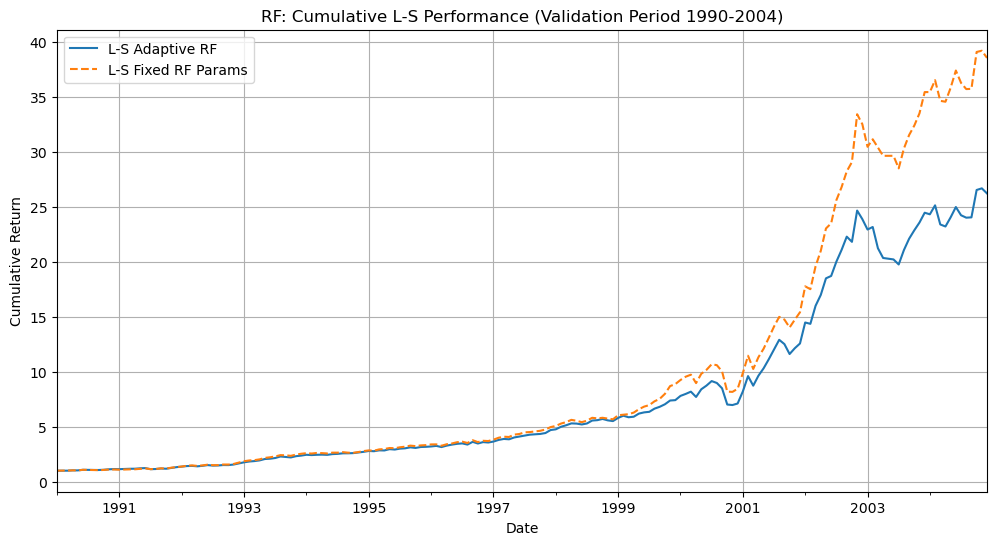

In [13]:
# --- Consolidate and Evaluate Results for Validation Period ---
print("\n--- Evaluating RF Performance on Validation Period (1990-2004) ---")

if results_rf_adaptive_cv:
    df_results_rf_adaptive = pd.concat(results_rf_adaptive_cv, ignore_index=True)
    mse_rf_adaptive = mean_squared_error(df_results_rf_adaptive['actual_ret'], df_results_rf_adaptive['predicted_ret_adaptive_rf'])
    if not y_train_initial.empty:
        mean_initial_train_ret = y_train_initial.mean()
        r2_oos_rf_adaptive = 1 - (np.sum((df_results_rf_adaptive['actual_ret'] - df_results_rf_adaptive['predicted_ret_adaptive_rf'])**2) / 
                                  np.sum((df_results_rf_adaptive['actual_ret'] - mean_initial_train_ret)**2))
    else:
        r2_oos_rf_adaptive = np.nan
        print("Warning: y_train_initial was empty, cannot compute OOS R2 for adaptive RF.")

    print(f"Adaptive RF Strategy (1990-2004):")
    print(f"  Overall MSE: {mse_rf_adaptive:.6f}")
    print(f"  Overall OOS R2 (vs initial train mean): {r2_oos_rf_adaptive:.4f}")

    df_params_rf = pd.DataFrame(params_chosen_rf_adaptive)
    print("\nHyperparameters chosen by Adaptive RF yearly:")
    print(df_params_rf)
    # Could plot these if desired, e.g., how max_depth changes

if results_rf_fixed_params:
    df_results_rf_fixed = pd.concat(results_rf_fixed_params, ignore_index=True)
    mse_rf_fixed = mean_squared_error(df_results_rf_fixed['actual_ret'], df_results_rf_fixed['predicted_ret_fixed_rf'])
    if not y_train_initial.empty:
        mean_initial_train_ret = y_train_initial.mean() # Redundant if already calculated but safe
        r2_oos_rf_fixed = 1 - (np.sum((df_results_rf_fixed['actual_ret'] - df_results_rf_fixed['predicted_ret_fixed_rf'])**2) / 
                               np.sum((df_results_rf_fixed['actual_ret'] - mean_initial_train_ret)**2))
    else:
        r2_oos_rf_fixed = np.nan
        print("Warning: y_train_initial was empty, cannot compute OOS R2 for fixed RF.")

    print(f"\nFixed RF Params Strategy (1990-2004):")
    print(f"  Overall MSE: {mse_rf_fixed:.6f}")
    print(f"  Overall OOS R2 (vs initial train mean): {r2_oos_rf_fixed:.4f}")

# --- Portfolio Sort Analysis (using the function from LASSO notebook, ensure it's defined here or imported) ---

if 'evaluate_portfolio_strategy' not in globals():
    print("\nWARNING: 'evaluate_portfolio_strategy' function not defined. Skipping portfolio analysis for RF.")
    print("Please define it (copy from LASSO notebook) to see portfolio results.")
else:
    ls_returns_rf_adaptive, quant_returns_rf_adaptive = evaluate_portfolio_strategy(df_results_rf_adaptive, 
                                                                                    'predicted_ret_adaptive_rf', 
                                                                                    'Adaptive RF (Validation)')
    ls_returns_rf_fixed, quant_returns_rf_fixed = evaluate_portfolio_strategy(df_results_rf_fixed, 
                                                                            'predicted_ret_fixed_rf', 
                                                                            'Fixed RF Params (Validation)')

    if ls_returns_rf_adaptive is not None and ls_returns_rf_fixed is not None:
        print("\n--- RF: Summary Comparison of Long-Short Strategies (Validation Period 1990-2004) ---")
        print(f"{'Metric':<30} {'Adaptive RF':<20} {'Fixed RF Params':<20}")
        print("-" * 70)
        
        mean_rf_adaptive = ls_returns_rf_adaptive.mean()
        sharpe_rf_adaptive = (mean_rf_adaptive / ls_returns_rf_adaptive.std()) * np.sqrt(12) if ls_returns_rf_adaptive.std() !=0 else 0
        
        mean_rf_fixed = ls_returns_rf_fixed.mean()
        sharpe_rf_fixed = (mean_rf_fixed / ls_returns_rf_fixed.std()) * np.sqrt(12) if ls_returns_rf_fixed.std() !=0 else 0
        
        print(f"{'Mean Monthly L-S Return':<30} {mean_rf_adaptive:<20.4%} {mean_rf_fixed:<20.4%}")
        print(f"{'Annualized L-S Sharpe Ratio':<30} {sharpe_rf_adaptive:<20.2f} {sharpe_rf_fixed:<20.2f}")

        plt.figure(figsize=(12,6))
        if ls_returns_rf_adaptive is not None:
            (1 + ls_returns_rf_adaptive).cumprod().plot(label='L-S Adaptive RF', legend=True)
        if ls_returns_rf_fixed is not None:
            (1 + ls_returns_rf_fixed).cumprod().plot(label='L-S Fixed RF Params', legend=True, linestyle='--')
        plt.title('RF: Cumulative L-S Performance (Validation Period 1990-2004)')
        plt.ylabel('Cumulative Return')
        plt.xlabel('Date')
        plt.grid(True)
        plt.show()
    else:
        print("\nCould not perform full RF comparison as one or both strategies did not yield sortable portfolio results.")

Decision for OOS Test Period (2005-2023):
Given these validation results, using the Fixed RF Parameters strategy (i.e., {'max_depth': 6, 'max_features': 50, 'min_samples_leaf': 50, 'min_samples_split': 50, 'n_estimators': 100 (or 300)}) for the final OOS test period (2005-2023) is now the more empirically supported choice.
It performed better on the key portfolio metrics (L-S return and Sharpe) during the validation period.
It's computationally much cheaper for the OOS run (no yearly GridSearchCV).
You have successfully used your validation period (1990-2004) to determine the best hyperparameter strategy for your Random Forest model, and in this case, a fixed set of well-chosen parameters (derived from an initial comprehensive CV) proved superior to yearly re-tuning for RF. This is a valuable finding in itself!

**OOS TEST LOOP**


--- Starting RandomForest OOS Test Period (Predicting for 2005-2023) ---
Using Fixed Hyperparameters (from initial 1965-1989 CV) with n_estimators=300
Using these fixed hyperparameters for OOS run: {'n_estimators': 300, 'max_depth': 6, 'max_features': 50, 'min_samples_leaf': 50, 'min_samples_split': 50, 'random_state': 42, 'n_jobs': -1}

Processing OOS for year to predict: 2005
  Training Fixed RF on 236910 obs from 1965-01-31 to 2004-12-31
  Year 2005 processed in 0.93 minutes.

Processing OOS for year to predict: 2006
  Training Fixed RF on 242751 obs from 1965-01-31 to 2005-12-31
  Year 2006 processed in 0.95 minutes.

Processing OOS for year to predict: 2007
  Training Fixed RF on 248548 obs from 1965-01-31 to 2006-12-31
  Year 2007 processed in 1.00 minutes.

Processing OOS for year to predict: 2008
  Training Fixed RF on 254315 obs from 1965-01-31 to 2007-12-31
  Year 2008 processed in 1.06 minutes.

Processing OOS for year to predict: 2009
  Training Fixed RF on 260067 obs from

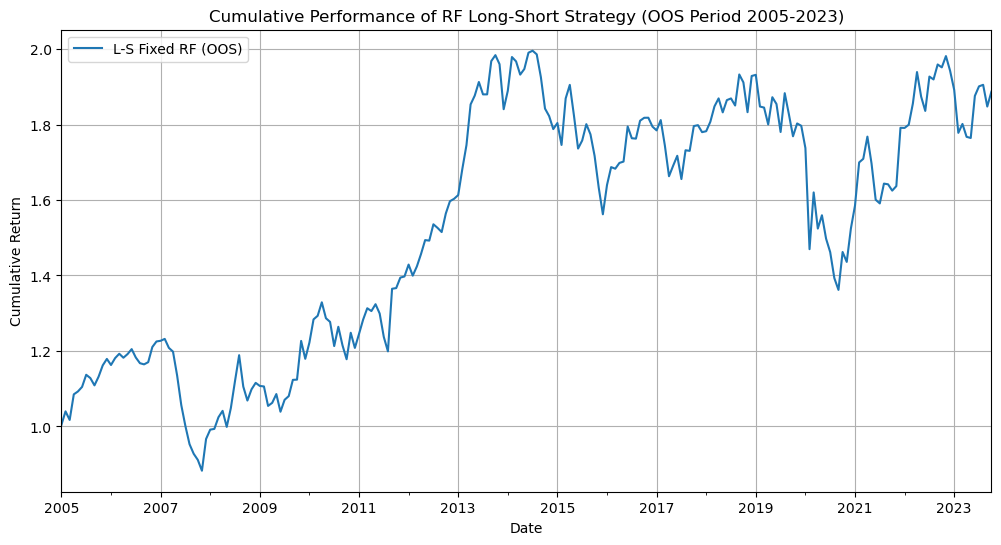


  Mean Monthly Rank IC (RF OOS): 0.0091
  Std Dev of Monthly Rank IC (RF OOS): 0.1303
  IC Sharpe (RF OOS Mean/Std): 0.07


C:\Users\Admin\AppData\Local\Temp\ipykernel_50988\356166718.py:104: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic_series_rf_oos = df_results_rf_oos.groupby('date').apply(calculate_rank_ic_rf)


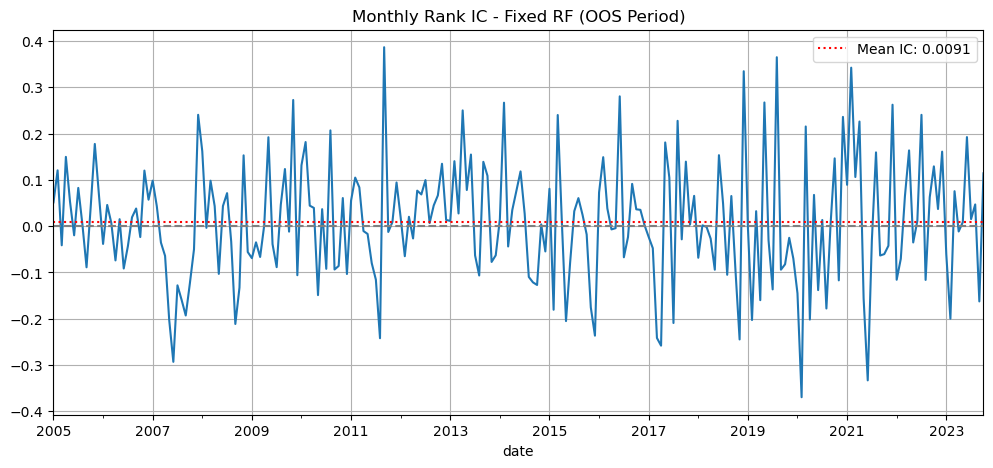


Random Forest OOS Test Period Analysis Complete.


In [14]:
print("\n--- Starting RandomForest OOS Test Period (Predicting for 2005-2023) ---")
print("Using Fixed Hyperparameters (from initial 1965-1989 CV) with n_estimators=300")

oos_predict_years = range(oos_test_start_date.year, oos_test_end_date.year + 1)

results_rf_oos_fixed_params = []

# Get the best parameters from the initial GridSearchCV and set n_estimators=300
best_initial_params = rf_grid_search.best_params_.copy()
current_fixed_hyperparams = {
    'n_estimators': 300, # As per paper
    'max_depth': best_initial_params.get('max_depth'),
    'max_features': best_initial_params.get('max_features'),
    'min_samples_leaf': best_initial_params.get('min_samples_leaf'),
    'min_samples_split': best_initial_params.get('min_samples_split'),
    'random_state': 42, # For reproducibility of the RF itself
    'n_jobs': -1         # For parallelism in RF tree building
}
print(f"Using these fixed hyperparameters for OOS run: {current_fixed_hyperparams}")

loop_start_time = time.time()

for year_to_predict in oos_predict_years:
    year_start_time = time.time()
    print(f"\nProcessing OOS for year to predict: {year_to_predict}")
    
    current_train_end_date = pd.to_datetime(f"{year_to_predict-1}-12-31")
    current_train_df = df[(df['date'] >= train_start_date) & (df['date'] <= current_train_end_date)].copy()
    
    current_test_start_date = pd.to_datetime(f"{year_to_predict}-01-01")
    current_test_end_date = pd.to_datetime(f"{year_to_predict}-12-31")
    current_test_df = df[(df['date'] >= current_test_start_date) & (df['date'] <= current_test_end_date)].copy()

    if current_train_df.empty or current_test_df.empty:
        print(f"  Skipping {year_to_predict}: not enough data for train ({len(current_train_df)}) or test ({len(current_test_df)}).")
        continue

    X_current_train = current_train_df[factor_columns]
    y_current_train = current_train_df[TARGET_COL]
    X_current_test = current_test_df[factor_columns]
    y_current_test_actual = current_test_df[TARGET_COL]

    print(f"  Training Fixed RF on {len(X_current_train)} obs from {train_start_date.date()} to {current_train_end_date.date()}")
    
    model_rf_oos = RandomForestRegressor(**current_fixed_hyperparams)
    model_rf_oos.fit(X_current_train, y_current_train)
    
    predictions_rf_oos = model_rf_oos.predict(X_current_test)
    results_rf_oos_fixed_params.append(pd.DataFrame({'date': current_test_df['date'],
                                                     'permno': current_test_df['permno'],
                                                     'actual_ret': y_current_test_actual,
                                                     'predicted_ret_fixed_rf': predictions_rf_oos}))
    year_end_time = time.time()
    print(f"  Year {year_to_predict} processed in {(year_end_time - year_start_time)/60:.2f} minutes.")

loop_end_time = time.time()
print(f"\nOOS Random Forest loop completed in {(loop_end_time - loop_start_time)/60:.2f} minutes.")

# --- Consolidate and Evaluate Results for OOS Test Period ---
print("\n--- Evaluating Fixed RF Performance on OOS Test Period (2005-2023) ---")

if results_rf_oos_fixed_params:
    df_results_rf_oos = pd.concat(results_rf_oos_fixed_params, ignore_index=True)
    
    # 1. Overall MSE and OOS R^2
    mse_rf_oos = mean_squared_error(df_results_rf_oos['actual_ret'], df_results_rf_oos['predicted_ret_fixed_rf'])
    mean_initial_train_ret = y_train_initial.mean() 
    r2_rf_oos = 1 - (np.sum((df_results_rf_oos['actual_ret'] - df_results_rf_oos['predicted_ret_fixed_rf'])**2) / 
                     np.sum((df_results_rf_oos['actual_ret'] - mean_initial_train_ret)**2))
    print(f"Fixed RF Params Strategy OOS (2005-2023):")
    print(f"  Overall MSE: {mse_rf_oos:.6f}")
    print(f"  Overall OOS R2 (vs initial train mean benchmark): {r2_rf_oos:.4f}")

    # 2. Portfolio Sort Analysis for OOS period
    # Ensure evaluate_portfolio_strategy function is defined in this notebook
    if 'evaluate_portfolio_strategy' not in globals():
        print("\nWARNING: 'evaluate_portfolio_strategy' function not defined. Skipping portfolio analysis for RF OOS.")
    else:
        N_QUANTILES = 10 # Make sure this is defined
        ls_returns_rf_oos, quant_returns_rf_oos = evaluate_portfolio_strategy(
            df_results_rf_oos, 
            'predicted_ret_fixed_rf', 
            'Fixed RF Params (OOS 2005-2023)'
        )
        if ls_returns_rf_oos is not None:
            print("\n--- Summary for OOS RF Long-Short Strategy (2005-2023) ---")
            mean_ls_rf_oos = ls_returns_rf_oos.mean()
            sharpe_ls_rf_oos = (mean_ls_rf_oos / ls_returns_rf_oos.std()) * np.sqrt(12) if ls_returns_rf_oos.std() !=0 else 0
            print(f"  Mean Monthly L-S Return: {mean_ls_rf_oos:.4%}")
            print(f"  Annualized L-S Sharpe Ratio: {sharpe_ls_rf_oos:.2f}")

            plt.figure(figsize=(12,6))
            (1 + ls_returns_rf_oos).cumprod().plot(label='L-S Fixed RF (OOS)', legend=True)
            plt.title('Cumulative Performance of RF Long-Short Strategy (OOS Period 2005-2023)')
            plt.ylabel('Cumulative Return')
            plt.xlabel('Date')
            plt.grid(True)
            plt.show()
            
            # 3. Information Coefficient (IC) - Example for Rank IC
            def calculate_rank_ic_rf(group):
                return group['predicted_ret_fixed_rf'].corr(group['actual_ret'], method='spearman')

            rank_ic_series_rf_oos = df_results_rf_oos.groupby('date').apply(calculate_rank_ic_rf)
            mean_rank_ic_rf_oos = rank_ic_series_rf_oos.mean()
            std_rank_ic_rf_oos = rank_ic_series_rf_oos.std()
            ic_sharpe_rf_oos = (mean_rank_ic_rf_oos / std_rank_ic_rf_oos)
            
            print(f"\n  Mean Monthly Rank IC (RF OOS): {mean_rank_ic_rf_oos:.4f}")
            print(f"  Std Dev of Monthly Rank IC (RF OOS): {std_rank_ic_rf_oos:.4f}")
            print(f"  IC Sharpe (RF OOS Mean/Std): {ic_sharpe_rf_oos:.2f}")

            plt.figure(figsize=(12,5))
            rank_ic_series_rf_oos.plot(title='Monthly Rank IC - Fixed RF (OOS Period)', legend=False)
            plt.axhline(0, color='grey', linestyle='--')
            plt.axhline(mean_rank_ic_rf_oos, color='red', linestyle=':', label=f'Mean IC: {mean_rank_ic_rf_oos:.4f}')
            plt.legend()
            plt.grid(True)
            plt.show()
else:
    print("No OOS results for RF to evaluate (results list is empty).")

print("\nRandom Forest OOS Test Period Analysis Complete.")


In [ ]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az # For MCMC diagnostics and visualization
import pytensor.tensor as pt # For more complex tensor operations if needed later
from sklearn.preprocessing import StandardScaler

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [ ]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az # For MCMC diagnostics and visualization
import pytensor.tensor as pt # For more complex tensor operations if needed later
from sklearn.preprocessing import StandardScaler

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Preliminary Model Performance: LASSO and Random Forest (Out-of-Sample 2005-2023)

This section summarizes the out-of-sample (OOS) performance of the LASSO and Random Forest models in predicting monthly S&P 500 constituent stock returns for the period January 2005 to December 2023. Both models were implemented using an expanding training window, with parameters and hyperparameters updated annually.

**Methodology Recap:**
*   **Data:** Monthly stock-level characteristics (153 factors, imputed and rank-standardized to [-1,1]) and future monthly returns for S&P 500 constituents from 1965-2023.
*   **Training:** Initial training from 1965-1989, validation of hyperparameter strategy from 1990-2004, and OOS testing from 2005-2023. Models were refit annually on an expanding window.
*   **LASSO:** The penalty term (λ) was adaptively re-tuned each year using 5-fold time-series cross-validation on the current expanding training data.
*   **Random Forest (RF):** Key hyperparameters (`max_depth`, `max_features`, `min_samples_leaf`, `min_samples_split`) were fixed based on an initial comprehensive cross-validation on the 1965-1989 data (as this strategy performed better than adaptive tuning during the 1990-2004 validation period). The number of trees (`n_estimators`) was set to 300.

**Out-of-Sample Performance Summary (2005-2023):**

| Metric                             | LASSO (Adaptive λ) | Random Forest (Fixed Params) | Notes                                                                 |
| :--------------------------------- | :------------------: | :----------------------------: | :-------------------------------------------------------------------- |
| **Overall MSE**                    |  0.008675  |           0.008655           | Lower is better.                                                      |
| **Overall OOS R²**                 | -0.0030  |           -0.0007            | Vs. initial (1965-1989) training mean. Higher (less negative) is better. |
| **L-S Portfolio: Mean Monthly Ret.** |       0.5045%        |           0.3452%            | Decile 10 - Decile 1, equal-weighted.                                 |
| **L-S Portfolio: Ann. Sharpe Ratio** |         0.43         |             0.33             | Assumes 0 risk-free rate.                                             |
| **Mean Monthly Rank IC**           |       0.0178         |           0.0091             | Spearman correlation between predictions and actual returns.        |
| **Rank IC Sharpe (Mean/Std)**      |         0.14         |             0.07             | Stability of IC.                                                      |

**Key Observations & Conclusions:**

1.  **Predictive Signal:** Both LASSO and Random Forest models demonstrate some level of predictive signal for stock returns in the OOS period, as evidenced by positive mean monthly returns for their respective long-short decile portfolios.
2.  **LASSO Performance:** The LASSO model with adaptive hyperparameter tuning generally exhibited stronger OOS performance across the key metrics. It achieved a higher long-short portfolio mean return (0.50% vs. 0.35% monthly) and a better Sharpe ratio (0.43 vs. 0.33) compared to the Random Forest. The Rank Information Coefficient for LASSO was also higher.
3.  **Random Forest Performance:** While the Random Forest generated positive long-short returns, its overall OOS R² was slightly negative, indicating it did not outperform the simple historical mean benchmark from the initial training period in terms of raw prediction accuracy. The monotonicity of its quantile sorts in the OOS period was also less consistent than desired, although the highest-predicting decile did outperform the lowest.
4.  **Challenges of OOS Prediction:** Both models showed a degradation in performance from their respective validation periods to the final OOS test period, underscoring the inherent difficulty and instability in predicting stock returns out-of-sample, especially over long horizons with varying market regimes (including the Global Financial Crisis and the COVID-19 pandemic within this test set).
5.  **Model Complexity vs. Performance:** In this instance, the linear LASSO model, despite its relative simplicity compared to Random Forest, provided more robust OOS results. This might suggest that with very noisy data like stock returns, more complex non-linear models like Random Forest can be harder to tune effectively or may be more prone to capturing noise if not carefully regularized, even with an expanding window approach. The fixed hyperparameter strategy for RF was chosen as it performed better in validation, but still underperformed LASSO OOS.

**Implications for Next Steps (Bayesian MCMC):**
The performance of these standard machine learning models provides a crucial benchmark. The LASSO model, with its ability to perform variable selection and produce sparse solutions, shows some promise. The subsequent application of a Bayesian MCMC framework will aim to:
    *   Potentially enhance predictor significance detection and model parameter robustness compared to LASSO's frequentist approach.
    *   Offer a more formal probabilistic approach to variable selection (via Posterior Inclusion Probabilities) and parameter uncertainty.
    *   Explore if a Bayesian approach can lead to improved and more stable out-of-sample predictive performance, particularly in constructing robust factor-timing or stock-selection strategies.

The results highlight that while signals are weak, there is evidence of predictability. The challenge lies in consistently capturing these signals, especially as market conditions evolve.